# 1、数据库导入与相关库的准备

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# 加载数据
df = pd.read_csv('./diabetes.csv')

# 查看数据基本信息
print("数据基本信息:")
print(df.info())
print("\n数据形状:", df.shape)
print("\n列名:", df.columns.tolist())
print("\n前5行数据:")
print(df.head())
print("\n数据统计描述:")
print(df.describe())
display(df.head())

数据基本信息:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

数据形状: (768, 9)

列名: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

前5行数据:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0           

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 2、数据预处理

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 重新加载数据
df = pd.read_csv('./diabetes.csv')

# 检查目标变量分布
print("目标变量分布:")
print(df['Outcome'].value_counts())
print(f"\n糖尿病患病率: {df['Outcome'].mean():.2%}")

# 检查异常值（0值在医学上不合理的特征）
print("\n异常值检查（0值统计）:")
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} 个0值 ({zero_count/len(df):.2%})")

# 处理异常值：用中位数替换0值
df_clean = df.copy()
for col in zero_columns:
    df_clean[col] = df_clean[col].replace(0, df_clean[col].median())

print("\n处理后的异常值检查:")
for col in zero_columns:
    zero_count = (df_clean[col] == 0).sum()
    print(f"{col}: {zero_count} 个0值")

# 按年龄分组分析
print("\n按年龄分组分析:")
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100], labels=['<30', '30-40', '40-50', '50-60', '>60'])
age_group_stats = df_clean.groupby('Age_Group').agg({
    'Outcome': ['count', 'mean'],
    'Glucose': 'mean',
    'BMI': 'mean',
    'BloodPressure': 'mean'
}).round(2)
print(age_group_stats)

# 特征相关性分析
print("\n特征相关性分析:")
correlation_matrix = df_clean.drop('Age_Group', axis=1).corr()
print("与Outcome的相关性:")
print(correlation_matrix['Outcome'].sort_values(ascending=False))

print("\n与Age的相关性:")
print(correlation_matrix['Age'].sort_values(ascending=False))


目标变量分布:
Outcome
0    500
1    268
Name: count, dtype: int64

糖尿病患病率: 34.90%

异常值检查（0值统计）:
Glucose: 5 个0值 (0.65%)
BloodPressure: 35 个0值 (4.56%)
SkinThickness: 227 个0值 (29.56%)
Insulin: 374 个0值 (48.70%)
BMI: 11 个0值 (1.43%)

处理后的异常值检查:
Glucose: 0 个0值
BloodPressure: 0 个0值
SkinThickness: 0 个0值
Insulin: 0 个0值
BMI: 0 个0值

按年龄分组分析:
          Outcome       Glucose    BMI BloodPressure
            count  mean    mean   mean          mean
Age_Group                                           
<30           417  0.22  115.02  32.01         69.12
30-40         157  0.48  126.92  32.89         73.94
40-50         113  0.57  125.92  34.50         77.34
50-60          54  0.57  141.15  31.71         80.06
>60            27  0.26  136.74  29.59         77.70

特征相关性分析:
与Outcome的相关性:
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
Diab

# 3、模型构建

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import json

In [4]:
# 重新加载和预处理数据
df = pd.read_csv('./diabetes.csv')
df_clean = df.copy()
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df_clean[col] = df_clean[col].replace(0, df_clean[col].median())

# 准备特征和目标变量
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']
feature_names = X.columns.tolist()

print("=== 特征选择分析 ===")

# 方法1：基于统计检验的特征选择 (SelectKBest with f_classif)
print("\n1. 基于统计检验的特征选择 (ANOVA F-value):")
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(X, y)
scores_f = selector_f.scores_
print("特征得分:")
for name, score in zip(feature_names, scores_f):
    print(f"{name}: {score:.4f}")

# 方法2：基于互信息的特征选择
print("\n2. 基于互信息的特征选择:")
selector_mi = SelectKBest(mutual_info_classif, k='all')
selector_mi.fit(X, y)
scores_mi = selector_mi.scores_
print("特征得分:")
for name, score in zip(feature_names, scores_mi):
    print(f"{name}: {score:.4f}")

# 方法3：递归特征消除 (RFE)
print("\n3. 递归特征消除 (RFE):")
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
selector_rfe = RFE(estimator, n_features_to_select=1, step=1)
selector_rfe.fit(X, y)
print("特征排名 (1=最重要):")
for name, rank in zip(feature_names, selector_rfe.ranking_):
    print(f"{name}: 排名 {rank}")

# 综合三种方法的特征重要性
print("\n=== 综合特征重要性分析 ===")
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'ANOVA_F': scores_f,
    'Mutual_Info': scores_mi,
    'RFE_Rank': selector_rfe.ranking_
})

# 归一化ANOVA和互信息得分
feature_importance['ANOVA_F_Norm'] = feature_importance['ANOVA_F'] / feature_importance['ANOVA_F'].max()
feature_importance['Mutual_Info_Norm'] = feature_importance['Mutual_Info'] / feature_importance['Mutual_Info'].max()
feature_importance['RFE_Score'] = 1 / feature_importance['RFE_Rank']  # 排名越低分数越高

# 计算综合得分
feature_importance['Overall_Score'] = (
    feature_importance['ANOVA_F_Norm'] * 0.3 +
    feature_importance['Mutual_Info_Norm'] * 0.3 +
    feature_importance['RFE_Score'] * 0.4
)

# 按综合得分排序
feature_importance = feature_importance.sort_values('Overall_Score', ascending=False)
print(feature_importance[['Feature', 'Overall_Score']].round(4))

# 准备训练数据
print("\n=== 准备模型训练数据 ===")
# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# 保存前10条样例数据用于可视化
sample_data = []
for i in range(min(10, len(df_clean))):
    sample_data.append({
        'Pregnancies': int(df_clean.iloc[i]['Pregnancies']),
        'Glucose': int(df_clean.iloc[i]['Glucose']),
        'BloodPressure': int(df_clean.iloc[i]['BloodPressure']),
        'SkinThickness': int(df_clean.iloc[i]['SkinThickness']),
        'Insulin': int(df_clean.iloc[i]['Insulin']),
        'BMI': float(df_clean.iloc[i]['BMI']),
        'DiabetesPedigreeFunction': float(df_clean.iloc[i]['DiabetesPedigreeFunction']),
        'Age': int(df_clean.iloc[i]['Age']),
        'Outcome': int(df_clean.iloc[i]['Outcome'])
    })

print(f"\n样例数据（前10条）已准备完成")

# 保存特征重要性数据
feature_importance_data = []
for _, row in feature_importance.iterrows():
    feature_importance_data.append({
        'feature': row['Feature'],
        'score': float(row['Overall_Score']),
        'anova_f': float(row['ANOVA_F']),
        'mutual_info': float(row['Mutual_Info']),
        'rfe_rank': int(row['RFE_Rank'])
    })

print(f"特征重要性数据已准备完成")

=== 特征选择分析 ===

1. 基于统计检验的特征选择 (ANOVA F-value):
特征得分:
Pregnancies: 39.6702
Glucose: 245.6679
BloodPressure: 21.6316
SkinThickness: 28.3963
Insulin: 17.2628
BMI: 82.7529
DiabetesPedigreeFunction: 23.8713
Age: 46.1406

2. 基于互信息的特征选择:
特征得分:
Pregnancies: 0.0368
Glucose: 0.1250
BloodPressure: 0.0299
SkinThickness: 0.0000
Insulin: 0.0408
BMI: 0.0773
DiabetesPedigreeFunction: 0.0120
Age: 0.0966

3. 递归特征消除 (RFE):
特征排名 (1=最重要):
Pregnancies: 排名 6
Glucose: 排名 1
BloodPressure: 排名 5
SkinThickness: 排名 7
Insulin: 排名 8
BMI: 排名 2
DiabetesPedigreeFunction: 排名 3
Age: 排名 4

=== 综合特征重要性分析 ===
                    Feature  Overall_Score
1                   Glucose         1.0000
5                       BMI         0.4865
7                       Age         0.3883
0               Pregnancies         0.2035
6  DiabetesPedigreeFunction         0.1913
2             BloodPressure         0.1782
4                   Insulin         0.1691
3             SkinThickness         0.0918

=== 准备模型训练数据 ===
训练集大小: (614, 8)


# 性能评估

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import json

# 重新加载和预处理数据
df = pd.read_csv('./diabetes.csv')
df_clean = df.copy()
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df_clean[col] = df_clean[col].replace(0, df_clean[col].median())

# 读取特征重要性结果，选择前N个特征,如果没有特征重要性数据则使用全部特征,主要为了使用上面的特征重要性结果
top_n_features = 5  # 可按需修改
all_features = df_clean.drop('Outcome', axis=1).columns.tolist()

if 'feature_importance_data' in globals() and len(feature_importance_data) > 0:
    ranked_features = [item['feature'] for item in feature_importance_data if item.get('feature') in all_features]
    selected_features = ranked_features[:min(top_n_features, len(ranked_features))]
    print(f"使用特征重要性前{len(selected_features)}个特征进行评估: {selected_features}")
else:
    selected_features = all_features
    print("未检测到 feature_importance_data，回退为使用全部特征进行评估")

# 准备特征和目标变量
X = df_clean[selected_features]
y = df_clean['Outcome']

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("=== 模型训练与评估 ===")

# 1. XGBoost基准模型
print("\n1. XGBoost模型:")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 预测
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 评估
xgb_results = {
    'model': 'XGBoost',
    'accuracy': float(accuracy_score(y_test, y_pred_xgb)),
    'precision': float(precision_score(y_test, y_pred_xgb)),
    'recall': float(recall_score(y_test, y_pred_xgb)),
    'f1_score': float(f1_score(y_test, y_pred_xgb)),
    'auc': float(roc_auc_score(y_test, y_prob_xgb))
}

print(f"准确率: {xgb_results['accuracy']:.4f}")
print(f"精确率: {xgb_results['precision']:.4f}")
print(f"召回率: {xgb_results['recall']:.4f}")
print(f"F1分数: {xgb_results['f1_score']:.4f}")
print(f"AUC: {xgb_results['auc']:.4f}")

# 2. 随机森林模型
print("\n2. 随机森林模型:")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    'model': 'Random Forest',
    'accuracy': float(accuracy_score(y_test, y_pred_rf)),
    'precision': float(precision_score(y_test, y_pred_rf)),
    'recall': float(recall_score(y_test, y_pred_rf)),
    'f1_score': float(f1_score(y_test, y_pred_rf)),
    'auc': float(roc_auc_score(y_test, y_prob_rf))
}

print(f"准确率: {rf_results['accuracy']:.4f}")
print(f"精确率: {rf_results['precision']:.4f}")
print(f"召回率: {rf_results['recall']:.4f}")
print(f"F1分数: {rf_results['f1_score']:.4f}")
print(f"AUC: {rf_results['auc']:.4f}")

# 3. 逻辑回归模型
print("\n3. 逻辑回归模型:")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

lr_results = {
    'model': 'Logistic Regression',
    'accuracy': float(accuracy_score(y_test, y_pred_lr)),
    'precision': float(precision_score(y_test, y_pred_lr)),
    'recall': float(recall_score(y_test, y_pred_lr)),
    'f1_score': float(f1_score(y_test, y_pred_lr)),
    'auc': float(roc_auc_score(y_test, y_prob_lr))
}

print(f"准确率: {lr_results['accuracy']:.4f}")
print(f"精确率: {lr_results['precision']:.4f}")
print(f"召回率: {lr_results['recall']:.4f}")
print(f"F1分数: {lr_results['f1_score']:.4f}")
print(f"AUC: {lr_results['auc']:.4f}")

# 4. SVM模型
print("\n4. SVM模型:")
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

svm_results = {
    'model': 'SVM',
    'accuracy': float(accuracy_score(y_test, y_pred_svm)),
    'precision': float(precision_score(y_test, y_pred_svm)),
    'recall': float(recall_score(y_test, y_pred_svm)),
    'f1_score': float(f1_score(y_test, y_pred_svm)),
    'auc': float(roc_auc_score(y_test, y_prob_svm))
}

print(f"准确率: {svm_results['accuracy']:.4f}")
print(f"精确率: {svm_results['precision']:.4f}")
print(f"召回率: {svm_results['recall']:.4f}")
print(f"F1分数: {svm_results['f1_score']:.4f}")
print(f"AUC: {svm_results['auc']:.4f}")

# 模型比较
print("\n=== 模型性能比较 ===")
models_results = [xgb_results, rf_results, lr_results, svm_results]
comparison_df = pd.DataFrame(models_results)
print(comparison_df.round(4))

# 找出最佳模型
best_auc_model = max(models_results, key=lambda x: x['auc'])
best_f1_model = max(models_results, key=lambda x: x['f1_score'])
best_acc_model = max(models_results, key=lambda x: x['accuracy'])

print(f"\n最佳AUC模型: {best_auc_model['model']} (AUC: {best_auc_model['auc']:.4f})")
print(f"最佳F1分数模型: {best_f1_model['model']} (F1: {best_f1_model['f1_score']:.4f})")
print(f"最佳准确率模型: {best_acc_model['model']} (准确率: {best_acc_model['accuracy']:.4f})")

# 准备模型调参 - XGBoost调参
print("\n=== XGBoost模型调参 ===")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证F1分数: {grid_search.best_score_:.4f}")

# 使用最佳参数重新训练
xgb_tuned = grid_search.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_tuned_results = {
    'model': 'XGBoost (Tuned)',
    'accuracy': float(accuracy_score(y_test, y_pred_xgb_tuned)),
    'precision': float(precision_score(y_test, y_pred_xgb_tuned)),
    'recall': float(recall_score(y_test, y_pred_xgb_tuned)),
    'f1_score': float(f1_score(y_test, y_pred_xgb_tuned)),
    'auc': float(roc_auc_score(y_test, y_prob_xgb_tuned))
}

print(f"\n调参后的XGBoost性能:")
print(f"准确率: {xgb_tuned_results['accuracy']:.4f}")
print(f"精确率: {xgb_tuned_results['precision']:.4f}")
print(f"召回率: {xgb_tuned_results['recall']:.4f}")
print(f"F1分数: {xgb_tuned_results['f1_score']:.4f}")
print(f"AUC: {xgb_tuned_results['auc']:.4f}")

# 比较调参前后
print("\n=== XGBoost调参前后比较 ===")
comparison_tuned = pd.DataFrame([xgb_results, xgb_tuned_results])
print(comparison_tuned.round(4))

# 保存结果数据
model_comparison_data = []
for result in [xgb_results, rf_results, lr_results, svm_results, xgb_tuned_results]:
    model_comparison_data.append({
        'model': result['model'],
        'accuracy': result['accuracy'],
        'precision': result['precision'],
        'recall': result['recall'],
        'f1_score': result['f1_score'],
        'auc': result['auc']
    })

print(f"\n模型比较数据已准备完成")

使用特征重要性前5个特征进行评估: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']
=== 模型训练与评估 ===

1. XGBoost模型:
准确率: 0.7208
精确率: 0.6038
召回率: 0.5926
F1分数: 0.5981
AUC: 0.7946

2. 随机森林模型:
准确率: 0.7597
精确率: 0.6667
召回率: 0.6296
F1分数: 0.6476
AUC: 0.8109

3. 逻辑回归模型:
准确率: 0.7013
精确率: 0.5870
召回率: 0.5000
F1分数: 0.5400
AUC: 0.8102

4. SVM模型:
准确率: 0.7273
精确率: 0.6429
召回率: 0.5000
F1分数: 0.5625
AUC: 0.7944

=== 模型性能比较 ===
                 model  accuracy  precision  recall  f1_score     auc
0              XGBoost    0.7208     0.6038  0.5926    0.5981  0.7946
1        Random Forest    0.7597     0.6667  0.6296    0.6476  0.8109
2  Logistic Regression    0.7013     0.5870  0.5000    0.5400  0.8102
3                  SVM    0.7273     0.6429  0.5000    0.5625  0.7944

最佳AUC模型: Random Forest (AUC: 0.8109)
最佳F1分数模型: Random Forest (F1: 0.6476)
最佳准确率模型: Random Forest (准确率: 0.7597)

=== XGBoost模型调参 ===
最佳参数: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
最佳交叉验证F1分数: 0.6554

调

库导入完成 | TensorFlow版本: 2.21.0
数据集形状: (768, 9)

数据集前5行:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

数据类型&缺失值:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 

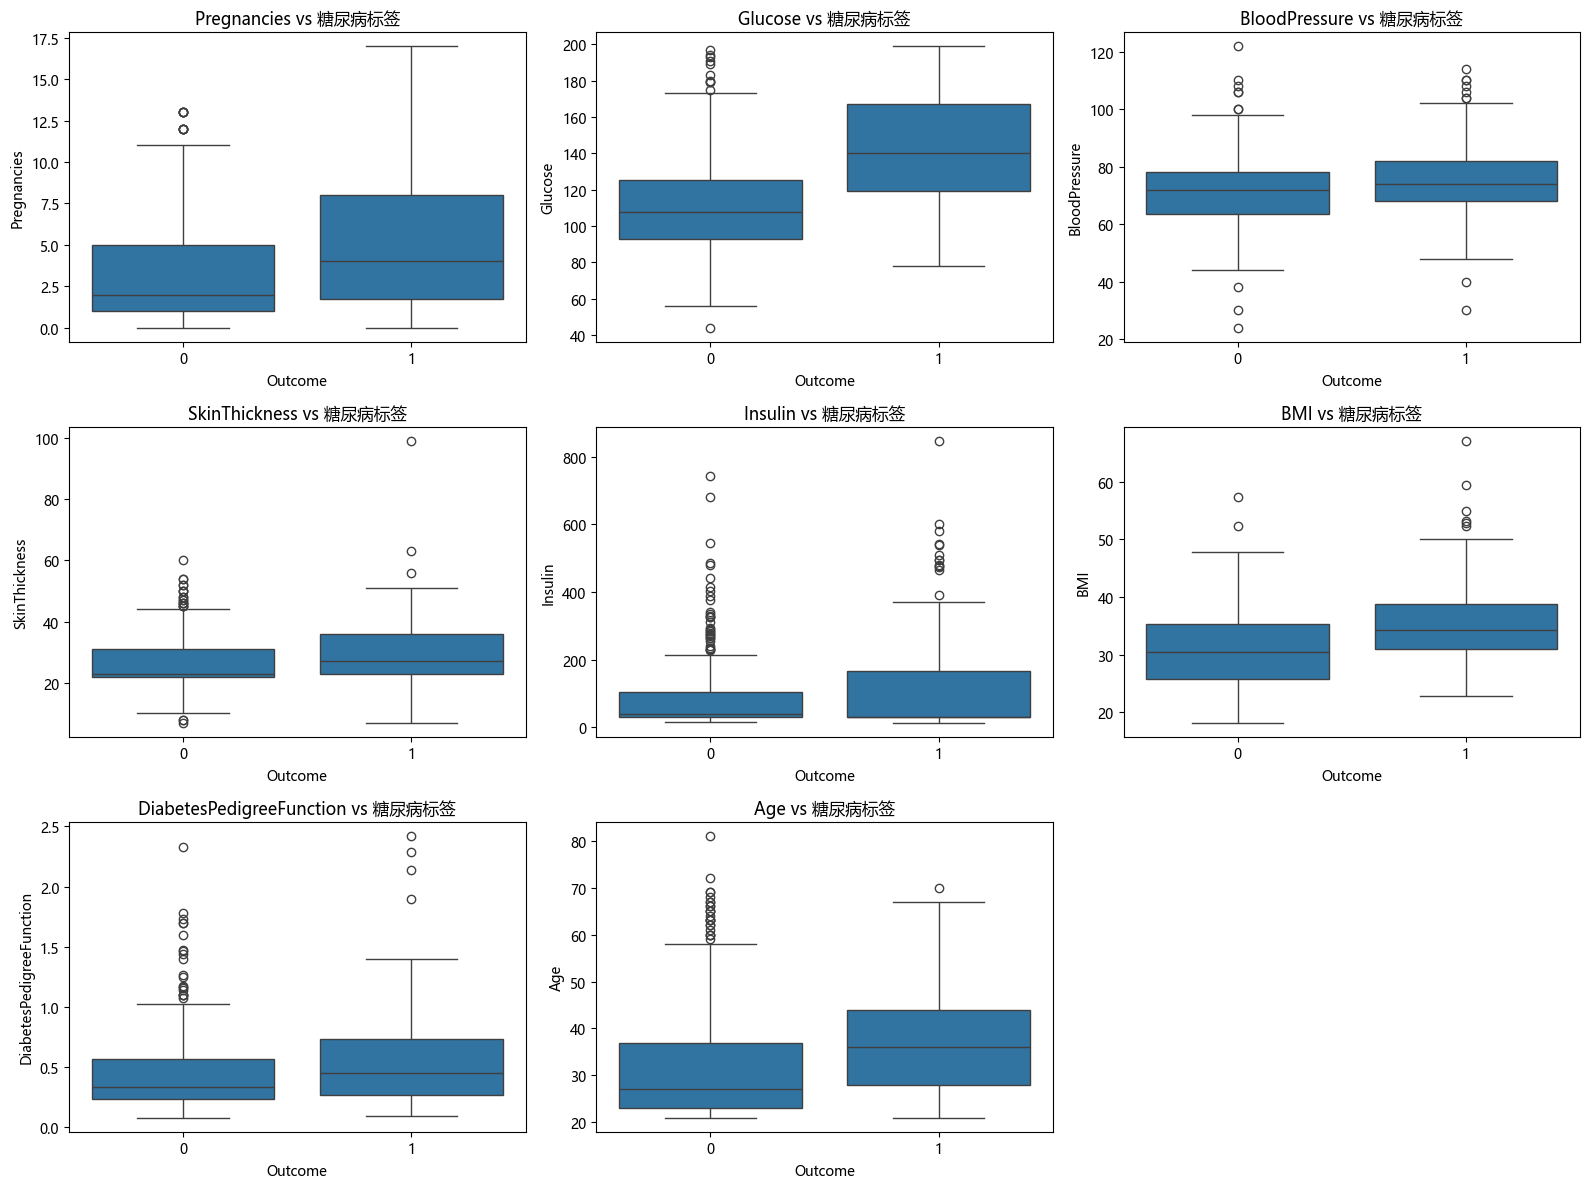

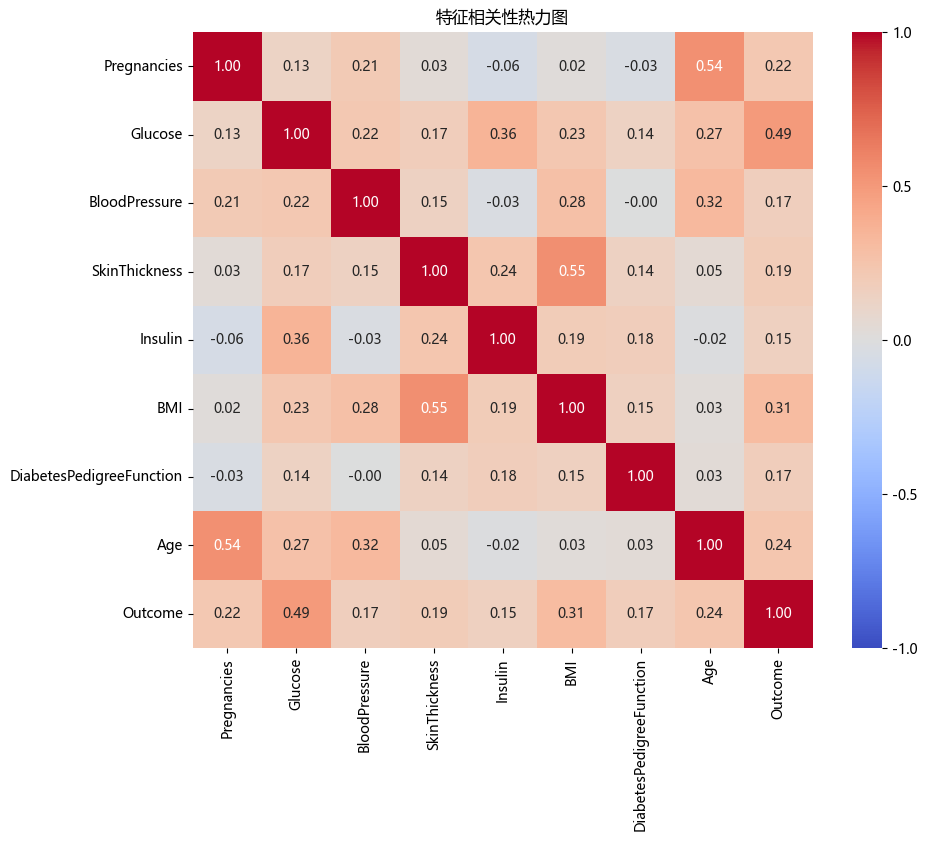


===== 两种RFE特征筛选 =====


In [1]:
# ===================== 1. 基础环境配置 & 库导入 =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 机器学习
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

# 深度学习
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# 模型可解释性
import shap
from lime import lime_tabular

from IPython.display import display, HTML

# 绘图设置
from matplotlib import font_manager as fm
import os
# 更稳健地加载中文字体：优先使用系统微软雅黑，如不存在则使用多个候选回退
font_path = r'C:\Windows\Fonts\msyh.ttf'
if os.path.exists(font_path):
    fp = fm.FontProperties(fname=font_path)
    font_name = fp.get_name()
    plt.rcParams['font.family'] = font_name
    plt.rcParams['font.sans-serif'] = [font_name]
else:
    # 尝试常见中文字体名作为回退（按顺序尝试）
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']

    
plt.rcParams['axes.unicode_minus'] = False
print("库导入完成 | TensorFlow版本:", tf.__version__)

# ===================== 2. 加载数据 & 基础信息查看 =====================
# Kaggle自带糖尿病数据集（T2DM临床数据）
df = pd.read_csv('./diabetes.csv')
print("数据集形状:", df.shape)
print("\n数据集前5行:")
print(df.head())
print("\n数据类型&缺失值:")
print(df.info())

# ===================== 3. 临床导向数据预处理 =====================
# T2DM临床常识：血糖、血压、皮厚、胰岛素、BMI=0为无效值，替换为中位数
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

# 划分特征与标签
X = df.drop('Outcome', axis=1)
y = df['Outcome']
feature_names = X.columns.tolist()

# 数据标准化（深度学习必备）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

# 训练集/测试集划分（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n预处理完成 | 训练集形状:", X_train.shape, "测试集形状:", X_test.shape)

# ===================== 4. 描述性统计 + 可视化 + 相关性分析 =====================
# 4.1 描述性统计
print("\n===== 描述性统计 =====")
print(df.describe().T)

# 4.2 特征分布可视化（箱线图+直方图）
plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_names, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} vs 糖尿病标签')
plt.tight_layout()
plt.show()

# 4.3 相关性热力图（临床特征关联性）
plt.figure(figsize=(10, 8))
corr = df.corr()
# 限定色阶为 [-1, 1]，并以 0 为中心，适合相关系数矩阵
sns.heatmap(corr.clip(-1, 1), annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, center=0,
            cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]})
plt.title('特征相关性热力图')
plt.show()

# ===================== 5. 双递归特征消除(RFE)筛选最优特征子集 =====================
# 目标：剔除冗余/噪声特征，保留T2DM高相关关键指标
print("\n===== 两种RFE特征筛选 =====")



逻辑回归RFE选中特征: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
XGBoost RFE选中特征: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
✅ 最优特征子集: ['DiabetesPedigreeFunction', 'Glucose', 'Insulin', 'Pregnancies', 'BMI', 'Age']
筛选后特征数: 6

构建临床交互后训练集形状: (614, 8)
最终输入特征: ['DiabetesPedigreeFunction', 'Glucose', 'Insulin', 'Pregnancies', 'BMI', 'Age', 'Glucose_BMI', 'Age_BMI']

===== 超参数调优中 =====
Reloading Tuner from tuner\t2dm\tuner0.json

===== 所有模型性能对比 =====
                模型     准确率     AUC      F1     精确率     召回率
1   Inception-LSTM  0.7403  0.8194  0.6296  0.6296  0.6296
3        XGBoost调优  0.7078  0.8106  0.3662  0.7647  0.2407
0        XGBoost基准  0.7273  0.7980  0.5962  0.6200  0.5741
4  Attention-CNN调优  0.7143  0.7978  0.4762  0.6667  0.3704
2    Attention-CNN  0.7338  0.7885  0.6168  0.6226  0.6111


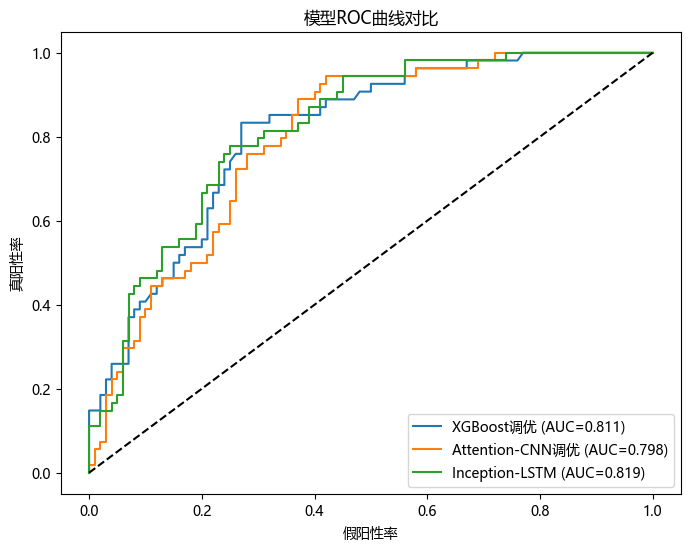

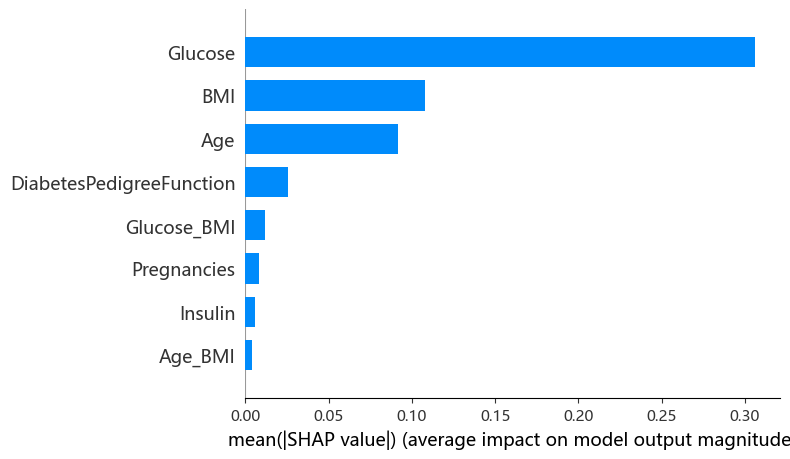

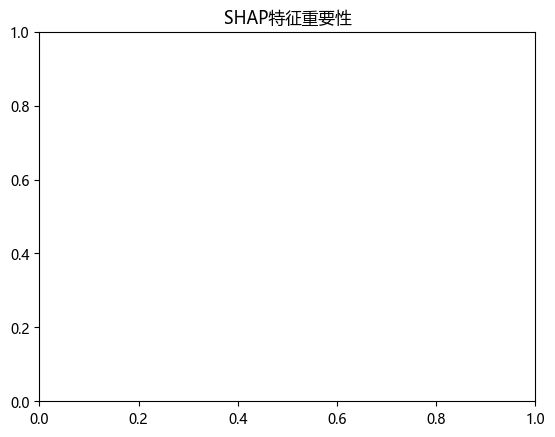

<Figure size 800x500 with 0 Axes>

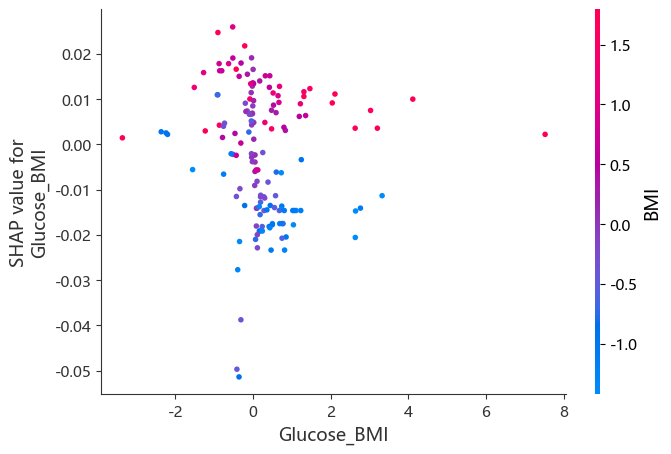

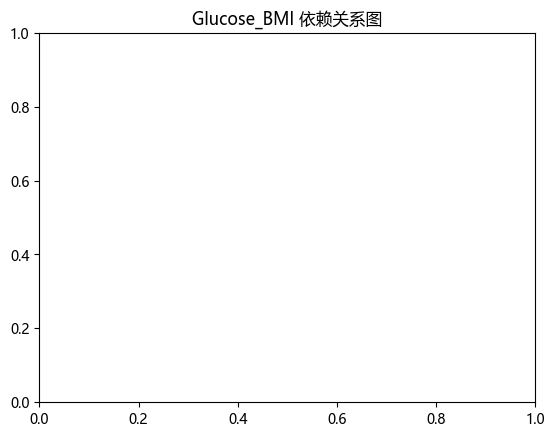


===== LIME个体预测解释 =====
样本5真实标签: 健康
模型预测患病概率: 27.14%



🎉 最优模型: Inception-LSTM
核心指标: 准确率=0.7403 | AUC=0.8194 | F1=0.6296


In [18]:
# 方法1：RFE + 逻辑回归（线性基准）
rfe_lr = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=6)
X_rfe_lr = rfe_lr.fit_transform(X_train, y_train)
lr_selected = [feature_names[i] for i in np.where(rfe_lr.support_)[0]]

# 方法2：RFE + XGBoost（树模型基准，更适配医疗数据）
rfe_xgb = RFE(estimator=XGBClassifier(random_state=42), n_features_to_select=6)
X_rfe_xgb = rfe_xgb.fit_transform(X_train, y_train)
xgb_selected = [feature_names[i] for i in np.where(rfe_xgb.support_)[0]]

# 取交集 → 最优临床特征子集（高稳定性）
best_features = list(set(lr_selected) & set(xgb_selected))
print(f"逻辑回归RFE选中特征: {lr_selected}")
print(f"XGBoost RFE选中特征: {xgb_selected}")
print(f"✅ 最优特征子集: {best_features}")

# 筛选最终特征
X_train_final = X_train[best_features]
X_test_final = X_test[best_features]
print(f"筛选后特征数: {len(best_features)}")

# ===================== 6. 结合T2DM临床机制构建特征交互项 =====================
# 临床公认交互：胰岛素抵抗(Glucose×BMI)、年龄代谢(Age×BMI)、血糖血压联合作用
def build_clinical_interaction(X, features):
    X_inter = X.copy()
    # 1. 血糖 × BMI（T2DM核心致病交互）
    if 'Glucose' in features and 'BMI' in features:
        X_inter['Glucose_BMI'] = X['Glucose'] * X['BMI']
    # 2. 年龄 × BMI（中老年肥胖风险）
    if 'Age' in features and 'BMI' in features:
        X_inter['Age_BMI'] = X['Age'] * X['BMI']
    # 3. 血糖 × 血压（代谢综合征核心）
    if 'Glucose' in features and 'BloodPressure' in features:
        X_inter['Glucose_BP'] = X['Glucose'] * X['BloodPressure']
    return X_inter

# 构建交互特征
X_train_clinical = build_clinical_interaction(X_train_final, best_features)
X_test_clinical = build_clinical_interaction(X_test_final, best_features)
print(f"\n构建临床交互后训练集形状: {X_train_clinical.shape}")
print(f"最终输入特征: {X_train_clinical.columns.tolist()}")

# 适配深度学习输入格式
input_dim = X_train_clinical.shape[1]
X_train_np = X_train_clinical.values
X_test_np = X_test_clinical.values

# ===================== 7. 模型构建：基准模型 + 2个指定深度学习模型 =====================
# 通用评估函数
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    auc = roc_auc_score(y_true, y_pred_proba)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    acc = np.mean(y_true == y_pred)
    res = {
        '模型': model_name, '准确率': round(acc,4), 'AUC': round(auc,4),
        'F1': round(f1,4), '精确率': round(precision,4), '召回率': round(recall,4)
    }
    return res

results = []

# -------------------- 基准模型：XGBoost（强基准） --------------------
xgb_base = XGBClassifier(random_state=42)
xgb_base.fit(X_train_clinical, y_train)
y_pred_xgb = xgb_base.predict(X_test_clinical)
y_pred_proba_xgb = xgb_base.predict_proba(X_test_clinical)[:,1]
results.append(evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, 'XGBoost基准'))

# -------------------- 深度学习1：Inception网络 + LSTM --------------------
def build_inception_lstm(input_dim):
    # 重塑为序列格式 (样本, 时间步, 特征)
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Reshape((1, input_dim))(inputs)
    
    # Inception多分支卷积
    branch1 = layers.Conv1D(32, 1, padding='same', activation='relu')(x)
    branch2 = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
    branch3 = layers.Conv1D(32, 5, padding='same', activation='relu')(x)
    concat = layers.concatenate([branch1, branch2, branch3], axis=-1)
    
    # LSTM提取时序特征
    lstm = layers.LSTM(64, return_sequences=False)(concat)
    # 全连接层
    dense = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(lstm)
    drop = layers.Dropout(0.3)(dense)
    outputs = layers.Dense(1, activation='sigmoid')(drop)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# -------------------- 深度学习2：注意力机制 + CNN --------------------
def build_attention_cnn(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)
    
    # CNN提取局部特征
    cnn = layers.Conv1D(64, 3, activation='relu')(x)
    cnn = layers.MaxPooling1D(2)(cnn)
    
    # 自注意力机制（聚焦关键临床特征）
    attention = layers.Attention()([cnn, cnn])
    flatten = layers.Flatten()(attention)
    
    # 全连接层
    dense = layers.Dense(32, activation='relu')(flatten)
    drop = layers.Dropout(0.3)(dense)
    outputs = layers.Dense(1, activation='sigmoid')(drop)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 训练基础深度学习模型
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Inception-LSTM
model_incep = build_inception_lstm(input_dim)
model_incep.fit(X_train_np, y_train, epochs=30, batch_size=8,
                validation_split=0.1, callbacks=[early_stop], verbose=0)
y_pred_incep = (model_incep.predict(X_test_np, verbose=0) > 0.5).astype(int).flatten()
y_pred_proba_incep = model_incep.predict(X_test_np, verbose=0).flatten()
results.append(evaluate_model(y_test, y_pred_incep, y_pred_proba_incep, 'Inception-LSTM'))

# Attention-CNN
model_att = build_attention_cnn(input_dim)
model_att.fit(X_train_np, y_train, epochs=30, batch_size=8,
              validation_split=0.1, callbacks=[early_stop], verbose=0)
y_pred_att = (model_att.predict(X_test_np, verbose=0) > 0.5).astype(int).flatten()
y_pred_proba_att = model_att.predict(X_test_np, verbose=0).flatten()
results.append(evaluate_model(y_test, y_pred_att, y_pred_proba_att, 'Attention-CNN'))

# ===================== 8. 超参数调优（提升AUC+准确率） =====================
print("\n===== 超参数调优中 =====")
# XGBoost调优
xgb_param = {
    'n_estimators': [50,100,200], 'max_depth': [3,5,7],
    'learning_rate': [0.01,0.1,0.2], 'subsample': [0.7,0.8,0.9]
}
xgb_search = RandomizedSearchCV(XGBClassifier(random_state=42), xgb_param,
                                n_iter=5, cv=3, scoring='roc_auc', random_state=42)
xgb_search.fit(X_train_clinical, y_train)
xgb_best = xgb_search.best_estimator_
y_pred_xgb_best = xgb_best.predict(X_test_clinical)
y_pred_proba_xgb_best = xgb_best.predict_proba(X_test_clinical)[:,1]
results.append(evaluate_model(y_test, y_pred_xgb_best, y_pred_proba_xgb_best, 'XGBoost调优'))

# 深度学习调优（Keras Tuner）
def model_builder(hp):
    hp_units = hp.Int('units', min_value=32, max_value=128, step=32)
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model = build_attention_cnn(input_dim)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(model_builder, objective='val_accuracy',
                        max_trials=3, directory='tuner', project_name='t2dm')
tuner.search(X_train_np, y_train, epochs=20, validation_split=0.1, verbose=0)
model_att_best = tuner.get_best_models(num_models=1)[0]
y_pred_att_best = (model_att_best.predict(X_test_np, verbose=0) > 0.5).astype(int).flatten()
y_pred_proba_att_best = model_att_best.predict(X_test_np, verbose=0).flatten()
results.append(evaluate_model(y_test, y_pred_att_best, y_pred_proba_att_best, 'Attention-CNN调优'))

# ===================== 9. 模型评估结果对比 =====================
res_df = pd.DataFrame(results)
print("\n===== 所有模型性能对比 =====")
print(res_df.sort_values(by='AUC', ascending=False))

# AUC曲线可视化
plt.figure(figsize=(8,6))
models = [('XGBoost调优', y_pred_proba_xgb_best),
          ('Attention-CNN调优', y_pred_proba_att_best),
          ('Inception-LSTM', y_pred_proba_incep)]
for name, prob in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('假阳性率')
plt.ylabel('真阳性率')
plt.title('模型ROC曲线对比')
plt.legend()
plt.show()

# ===================== 10. SHAP + LIME 模型可解释性（临床可解释） =====================
# 10.1 SHAP分析（最优模型：XGBoost调优）
explainer_shap = shap.TreeExplainer(xgb_best)
shap_values = explainer_shap.shap_values(X_test_clinical)

# SHAP特征重要性图谱
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_clinical, plot_type='bar')
plt.title('SHAP特征重要性')
plt.show()

# SHAP依赖关系图（核心特征：Glucose_BMI）
plt.figure(figsize=(8,5))
shap.dependence_plot('Glucose_BMI', shap_values, X_test_clinical)
plt.title('Glucose_BMI 依赖关系图')
plt.show()

# 10.2 LIME局部解释（个体预测影响）
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_clinical.values,
    feature_names=X_train_clinical.columns.tolist(),
    class_names=['健康', '糖尿病'],
    mode='classification'
)

# 随机选1个样本解释
idx = 5
exp = explainer_lime.explain_instance(
    data_row=X_test_clinical.iloc[idx].values,
    predict_fn=xgb_best.predict_proba,
    num_features=5
)
print("\n===== LIME个体预测解释 =====")
print(f"样本{idx}真实标签: {'糖尿病' if y_test.iloc[idx]==1 else '健康'}")
print(f"模型预测患病概率: {xgb_best.predict_proba(X_test_clinical.iloc[idx:idx+1])[0][1]:.2%}")
display(HTML(exp.as_html(show_table=True)))

# ===================== 11. 最优模型总结 =====================
best_model = res_df.sort_values(by='AUC', ascending=False).iloc[0]
print(f"\n🎉 最优模型: {best_model['模型']}")
print(f"核心指标: 准确率={best_model['准确率']} | AUC={best_model['AUC']} | F1={best_model['F1']}")